In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from nltk.probability import FreqDist
import pymorphy3

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [4]:
with open('2016.txt', 'r') as file:
    data = file.read()

In [9]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

In [10]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [13]:
tokenized = tokenize_text(data)

In [15]:
all_words = FreqDist(tokenized)

In [17]:
print("Наиболлее популярные слова: ", all_words.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words.keys()))

Наиболлее популярные слова:  [('брикс', 105), ('страна', 77), ('развитие', 77), ('международный', 57), ('цель', 55), ('сотрудничество', 53), ('приветствовать', 53), ('наш', 49), ('также', 46), ('вопрос', 45), ('оон', 41), ('который', 38), ('обеспечение', 38), ('подчёркивать', 34), ('устойчивый', 34), ('экономический', 33), ('безопасность', 30), ('государство', 30), ('глобальный', 28), ('число', 27), ('отмечать', 26), ('важность', 25), ('связь', 25), ('подтверждать', 25), ('роль', 25), ('область', 25), ('рост', 24), ('рамка', 23), ('мир', 22), ('укрепление', 21), ('усилие', 21), ('сфера', 21), ('реализация', 20), ('принцип', 20), ('включая', 20), ('встреча', 19), ('терроризм', 19), ('день', 19), ('право', 18), ('необходимость', 18), ('повестка', 18), ('мера', 17), ('должный', 17), ('борьба', 17), ('создание', 17), ('технология', 17), ('индия', 16), ('вызов', 16), ('вновь', 16), ('это', 16), ('являться', 16), ('соответствие', 16), ('призывать', 16), ('возможность', 15), ('продвижение', 1

C:\Temp\ipykernel_12640\1563493910.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


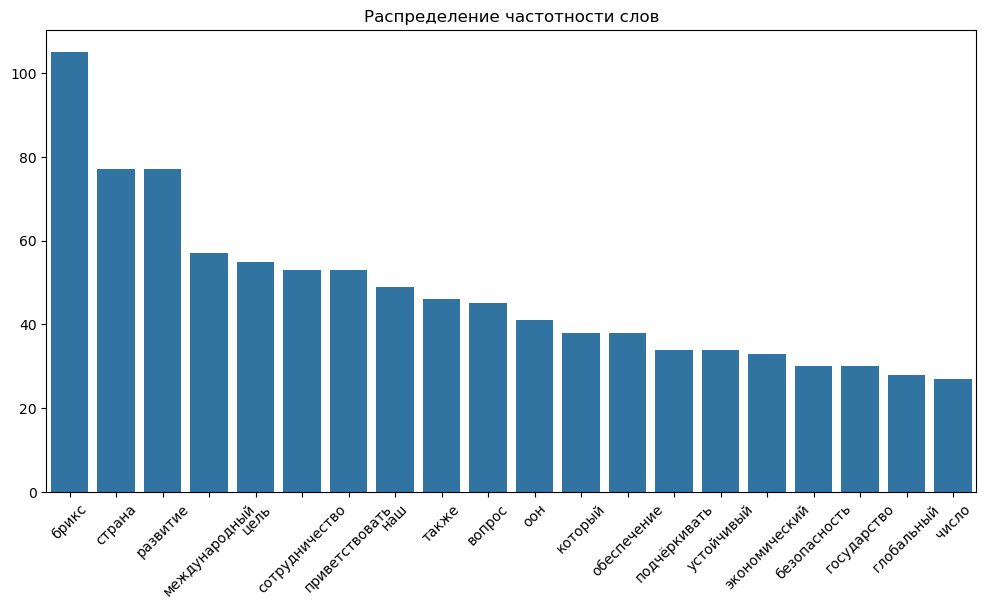

In [19]:
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [21]:
stop_words_ex = ['год','наш', 'который', 'также']
def stop_words_extra(text):
    return [w for w in text if not w in stop_words_ex]

In [23]:
tokens = stop_words_extra(tokenized)

C:\Temp\ipykernel_12640\3051857113.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


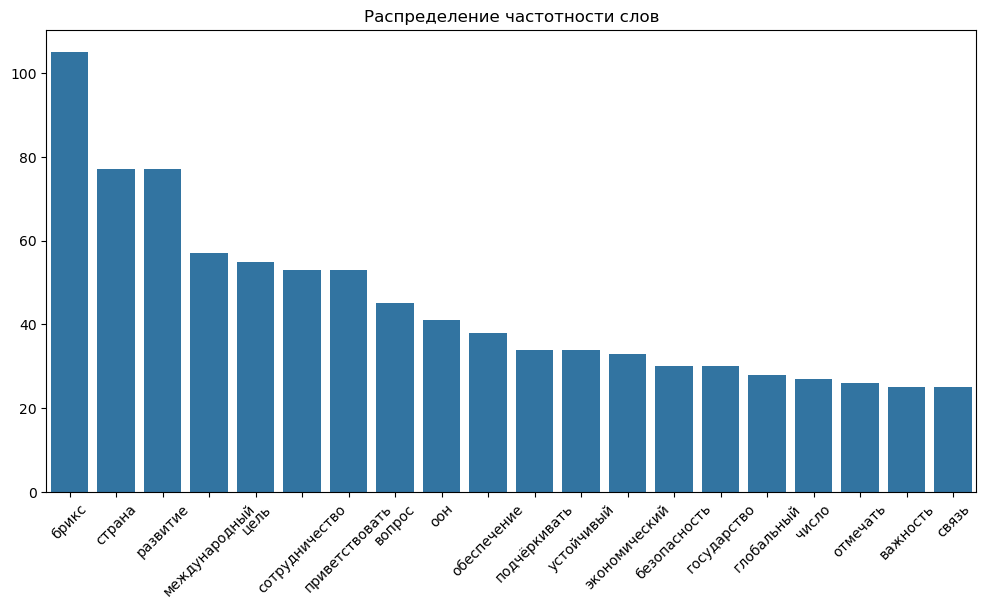

In [25]:
all_words = FreqDist(tokens)
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [27]:
textt = ','.join(w for w in tokens)

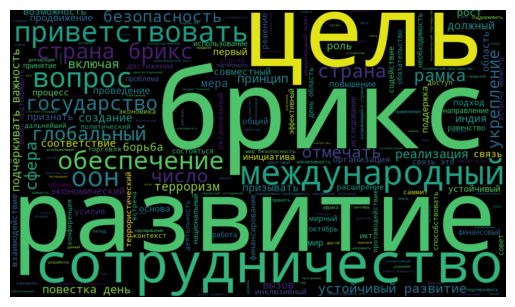

In [29]:
wordcloud = WordCloud(width=950,height=550).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [31]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(tokens)

### Латентное размещение Дерихле

In [34]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=2, random_state=42)

In [35]:
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['глобальный', 'безопасность', 'экономический', 'устойчивый', 'обеспечение', 'оон', 'международный', 'развитие', 'страна', 'брикс']


Top 10 words for topic #1:
['сфера', 'связь', 'подтверждать', 'важность', 'государство', 'подчёркивать', 'вопрос', 'приветствовать', 'сотрудничество', 'цель']




In [36]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['связь', 'роль', 'отмечать', 'число', 'экономический', 'устойчивый', 'обеспечение', 'оон', 'страна', 'развитие']


Top 10 words for topic #1:
['создание', 'мера', 'повестка', 'встреча', 'усилие', 'важность', 'подчёркивать', 'вопрос', 'приветствовать', 'цель']


Top 10 words for topic #2:
['укрепление', 'рамка', 'рост', 'подтверждать', 'глобальный', 'безопасность', 'государство', 'сотрудничество', 'международный', 'брикс']




### Неотрицательная матричная факторизация

In [108]:
nmf = NMF(n_components=2, random_state=42)
nmf.fit(doc_term_matrix )
for i,topic in enumerate(nmf.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['укрепление', 'экономика', 'бразилия', 'поддерживать', 'вопрос', 'африка', 'китай', 'встреча', 'международный', 'сотрудничество']


Top 10 words for topic #1:
['рамка', 'индия', 'экономика', 'вопрос', 'китай', 'проведение', 'страна', 'развитие', 'международный', 'брикс']




Вывод: тематика декларации 2016 г. посвящена общим вопросам международного сотрудничества